<a href="https://colab.research.google.com/github/Abdullah-Sayeed7/projects/blob/main/cnn2_SAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [57]:
img1 = cv2.imread("/content/san_1.bmp", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("/content/san_2.bmp", cv2.IMREAD_GRAYSCALE)
gt   = cv2.imread("/content/san_gt.bmp", cv2.IMREAD_GRAYSCALE)

img1_f = img1.astype(np.float32) + 1e-10
img2_f = img2.astype(np.float32) + 1e-10

def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-10)

log_ratio = normalize(np.abs(np.log(img1_f) - np.log(img2_f)))
labels    = (gt > 128).astype(np.int64).flatten()

print(f"Changed: {labels.sum()} | Unchanged: {(labels==0).sum()}")

Changed: 4685 | Unchanged: 60851


In [58]:
def extract_patches_fast(image, patch_size=7):
    h, w  = image.shape
    pad   = patch_size // 2
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)

    shape   = (h, w, patch_size, patch_size)
    strides = (padded.strides[0], padded.strides[1],
               padded.strides[0], padded.strides[1])

    patches = np.lib.stride_tricks.as_strided(padded, shape=shape, strides=strides)
    return patches.reshape(-1, patch_size, patch_size)

PATCH_SIZE = 13
patches = extract_patches_fast(log_ratio, PATCH_SIZE)
patches.shape

(65536, 13, 13)

In [59]:
H, W = 256, 256

label_grid = labels.reshape(H, W)
patch_grid = patches.reshape(H, W, PATCH_SIZE, PATCH_SIZE)

split_col = int(W * 0.7)

train_mask = np.zeros((H, W), dtype=bool)
train_mask[:, :split_col] = True
test_mask = ~train_mask

X_tr = torch.tensor(patch_grid[train_mask][:, np.newaxis], dtype=torch.float32)
X_te = torch.tensor(patch_grid[test_mask][:, np.newaxis],  dtype=torch.float32)
y_tr = torch.tensor(label_grid[train_mask], dtype=torch.long)
y_te = torch.tensor(label_grid[test_mask],  dtype=torch.long)

X = torch.tensor(patches[:, np.newaxis], dtype=torch.float32)
y = torch.tensor(labels, dtype=torch.long)

print(f"Train: {X_tr.shape[0]} pixels (columns 0-{split_col-1})")
print(f"Test:  {X_te.shape[0]} pixels (columns {split_col}-{W-1})")
print(f"Train changed: {y_tr.sum()} | Test changed: {y_te.sum()}")

loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=512, shuffle=True)

Train: 45824 pixels (columns 0-178)
Test:  19712 pixels (columns 179-255)
Train changed: 4133 | Test changed: 552


In [60]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 13 → 6
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 6 → 3
            nn.Flatten(),
            nn.Linear(128*3*3, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 2)
        )
    def forward(self, x): return self.net(x)

model = SimpleCNN().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 167,042


In [61]:
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, 10.0]).to(device)
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

EPOCHS = 30
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg = total_loss / len(loader)
    scheduler.step(avg)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg:.4f}")

Epoch   5/30 | Loss: 0.0297
Epoch  10/30 | Loss: 0.0176
Epoch  15/30 | Loss: 0.0124
Epoch  20/30 | Loss: 0.0109
Epoch  25/30 | Loss: 0.0127
Epoch  30/30 | Loss: 0.0067


In [62]:
def evaluate(model, X_input, y_true, label=""):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for i in range(0, len(X_input), 1024):
            out = model(X_input[i:i+1024].to(device))
            all_preds.extend(torch.argmax(out, 1).cpu().numpy())
    preds = np.array(all_preds)
    true  = y_true.numpy()

    TP = ((preds==1)&(true==1)).sum()
    TN = ((preds==0)&(true==0)).sum()
    FP = ((preds==1)&(true==0)).sum()
    FN = ((preds==0)&(true==1)).sum()
    OE  = FP + FN
    PCC = (TP+TN) / len(true) * 100
    d   = (TP+FP)*(FP+TN) + (TP+FN)*(FN+TN)
    KC  = 2*(TP*TN - FP*FN) / d * 100 if d else 0

    print(f"\n {label} ")
    print(f"FP: {FP}  FN: {FN}  OE: {OE}")
    print(f"PCC: {PCC:.2f}%  KC: {KC:.2f}%")
    return preds

te_preds  = evaluate(model, X_te, y_te,    label="TEST SET (30% held-out)")
all_preds = evaluate(model, X,    y,        label="FULL IMAGE")


 TEST SET (30% held-out) 
FP: 34  FN: 152  OE: 186
PCC: 99.06%  KC: 80.66%

 FULL IMAGE 
FP: 96  FN: 152  OE: 248
PCC: 99.62%  KC: 97.13%


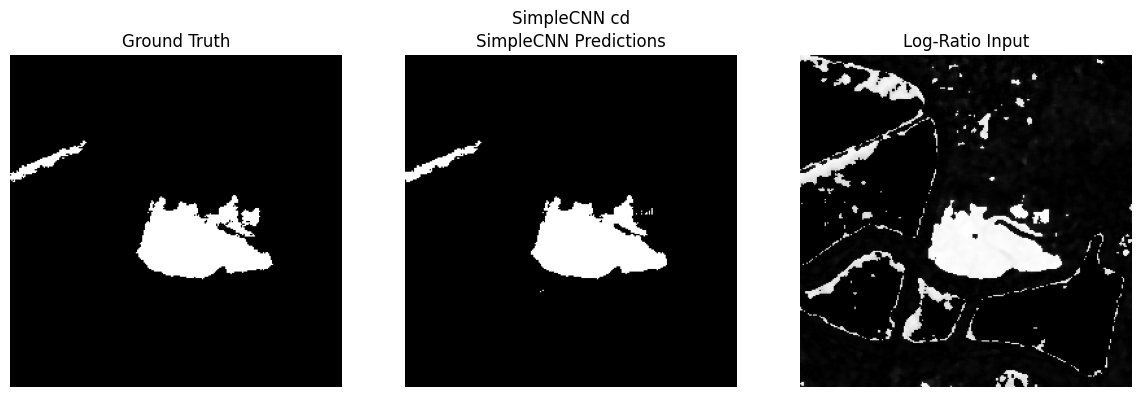

In [63]:
pred_map = all_preds.reshape(256, 256)
gt_map   = labels.reshape(256, 256)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gt_map,        cmap='gray'); axes[0].set_title("Ground Truth")
axes[1].imshow(pred_map,      cmap='gray'); axes[1].set_title("SimpleCNN Predictions")
axes[2].imshow(log_ratio,     cmap='gray'); axes[2].set_title("Log-Ratio Input")
for ax in axes: ax.axis('off')
plt.suptitle("SimpleCNN cd")
plt.tight_layout(); plt.show()

In [64]:
## Patch size = 7

In [65]:
def extract_patches_fast(image, patch_size=7):
    h, w  = image.shape
    pad   = patch_size // 2
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)

    shape   = (h, w, patch_size, patch_size)
    strides = (padded.strides[0], padded.strides[1],
               padded.strides[0], padded.strides[1])

    patches = np.lib.stride_tricks.as_strided(padded, shape=shape, strides=strides)
    return patches.reshape(-1, patch_size, patch_size)

PATCH_SIZE = 7
patches = extract_patches_fast(log_ratio, PATCH_SIZE)
patches.shape

(65536, 7, 7)

In [66]:
H, W = 256, 256

label_grid = labels.reshape(H, W)
patch_grid = patches.reshape(H, W, PATCH_SIZE, PATCH_SIZE)

split_col = int(W * 0.7)

train_mask = np.zeros((H, W), dtype=bool)
train_mask[:, :split_col] = True
test_mask = ~train_mask

X_tr = torch.tensor(patch_grid[train_mask][:, np.newaxis], dtype=torch.float32)
X_te = torch.tensor(patch_grid[test_mask][:, np.newaxis],  dtype=torch.float32)
y_tr = torch.tensor(label_grid[train_mask], dtype=torch.long)
y_te = torch.tensor(label_grid[test_mask],  dtype=torch.long)

X = torch.tensor(patches[:, np.newaxis], dtype=torch.float32)
y = torch.tensor(labels, dtype=torch.long)

print(f"Train: {X_tr.shape[0]} pixels (columns 0-{split_col-1})")
print(f"Test:  {X_te.shape[0]} pixels (columns {split_col}-{W-1})")
print(f"Train changed: {y_tr.sum()} | Test changed: {y_te.sum()}")

loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=512, shuffle=True)

Train: 45824 pixels (columns 0-178)
Test:  19712 pixels (columns 179-255)
Train changed: 4133 | Test changed: 552


In [67]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 2)
        )
    def forward(self, x): return self.net(x)

model = SimpleCNN().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 101,506


In [68]:
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, 10.0]).to(device)
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

EPOCHS = 30
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg = total_loss / len(loader)
    scheduler.step(avg)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg:.4f}")

Epoch   5/30 | Loss: 0.0539
Epoch  10/30 | Loss: 0.0361
Epoch  15/30 | Loss: 0.0276
Epoch  20/30 | Loss: 0.0318
Epoch  25/30 | Loss: 0.0252
Epoch  30/30 | Loss: 0.0181


In [69]:
def evaluate(model, X_input, y_true, label=""):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for i in range(0, len(X_input), 1024):
            out = model(X_input[i:i+1024].to(device))
            all_preds.extend(torch.argmax(out, 1).cpu().numpy())
    preds = np.array(all_preds)
    true  = y_true.numpy()

    TP = ((preds==1)&(true==1)).sum()
    TN = ((preds==0)&(true==0)).sum()
    FP = ((preds==1)&(true==0)).sum()
    FN = ((preds==0)&(true==1)).sum()
    OE  = FP + FN
    PCC = (TP+TN) / len(true) * 100
    d   = (TP+FP)*(FP+TN) + (TP+FN)*(FN+TN)
    KC  = 2*(TP*TN - FP*FN) / d * 100 if d else 0

    print(f"\n {label} ")
    print(f"FP: {FP}  FN: {FN}  OE: {OE}")
    print(f"PCC: {PCC:.2f}%  KC: {KC:.2f}%")
    return preds

te_preds  = evaluate(model, X_te, y_te,    label="TEST SET (30% held-out)")
all_preds = evaluate(model, X,    y,        label="FULL IMAGE")


 TEST SET (30% held-out) 
FP: 40  FN: 115  OE: 155
PCC: 99.21%  KC: 84.54%

 FULL IMAGE 
FP: 163  FN: 220  OE: 383
PCC: 99.42%  KC: 95.57%


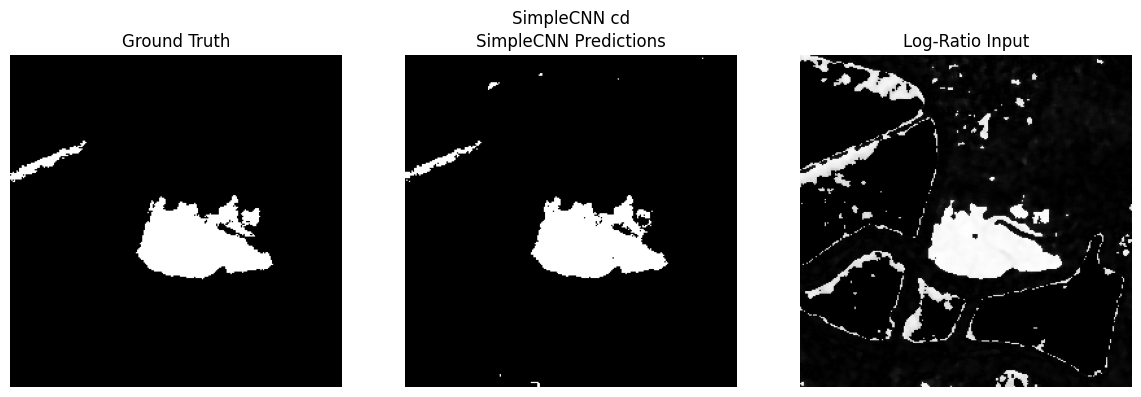

In [70]:
pred_map = all_preds.reshape(256, 256)
gt_map   = labels.reshape(256, 256)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gt_map,        cmap='gray'); axes[0].set_title("Ground Truth")
axes[1].imshow(pred_map,      cmap='gray'); axes[1].set_title("SimpleCNN Predictions")
axes[2].imshow(log_ratio,     cmap='gray'); axes[2].set_title("Log-Ratio Input")
for ax in axes: ax.axis('off')
plt.suptitle("SimpleCNN cd")
plt.tight_layout(); plt.show()